<span style="font-size:2em; font-weight:bold;"> Grenada Rainfall Analysis: Intensity Duration Frequency (IDF) Curve Development - Bayesian Inference Monte Carlo Markov Chain (MCMC) Analysis</span>
***

This code was written to produce IDF curves for Grenada using the two Extreme Value Analysis regimes:

1) Generalized pareto distribution (GPD)
2) General Extreme Value (GEV)

# 1.0 Import modules and data

## 1.1 Import modules

In [16]:
# basic modules
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)
import seaborn as sns
from scipy.stats import skewnorm, t, invgamma
from IPython.display import clear_output

# Numpyro/Jax libraries
import arviz as az
import numpyro as numpyro
print('numpyro v' + str(numpyro.__version__))
import jax as jax
print('jax v' + str(jax.__version__))
# Change JAX default from float32 to float64
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from jax import lax
from jax.scipy.special import log_ndtr
import numpyro.distributions as dist
from numpyro.distributions import constraints
from numpyro.distributions.distribution import Distribution
from numpyro.distributions.util import promote_shapes
from numpyro.util import is_prng_key
from numpyro.infer import MCMC, NUTS, Predictive, log_likelihood

numpyro.set_platform("cpu")

# Number of CPUs -> To sample several MCMC chains in parallel
numpyro.set_host_device_count(4)
numpyro.enable_validation(True)

from pyextremes import get_extremes

# compute return levels
from return_levels import exceedance_rate_per_year, gev_return_levels_from_posterior, gpd_return_levels_from_posterior

numpyro v0.18.0
jax v0.5.3


## 1.2 Import data

In [17]:
# station names and locations
stations = pd.read_excel(r'Data\GRN_RAINFALL_DATA_NAWASA_2025.xlsx',sheet_name='Raingauge Coordinates')

# imputed rainfall data
grn_rainfall_imput = pd.read_csv(r'Outputs\GRN_RAINFALL_MODELElev_FINAL_n6_thr25mm_var0p25.csv') # D8020 split
# grn_rainfall_imput = pd.read_csv(r'Outputs\GRN_RAINFALL_MODELElev_FINAL_n6_thr25mm_var0p25_full.csv') # D8020 split

grn_rainfall_imput['date'] = pd.to_datetime(grn_rainfall_imput['date'], errors='coerce')
grn_rainfall_imput = grn_rainfall_imput.set_index('date').sort_index()

# get thresholds
pots_thr =  pd.read_csv(r'Outputs\pots_thresholds.csv')

# get station names from columns
station_ids = grn_rainfall_imput.columns.tolist()

# 2.0 Jax/Numpyro model definitions

## 2.1 Skew_normal distribution

In [18]:
class SkewNormalPrior(Distribution):
    arg_constraints = {
        "loc": constraints.real,
        "scale": constraints.positive,
        "alpha": constraints.real,
    }
    support = constraints.real
    has_rsample = False

    def __init__(self, loc, scale, alpha, validate_args=None):
        batch_shape = lax.broadcast_shapes(
            jnp.shape(loc), jnp.shape(scale), jnp.shape(alpha)
        )
        self.loc, self.scale, self.alpha = promote_shapes(
            loc, scale, alpha, shape=batch_shape
        )
        super().__init__(batch_shape=batch_shape, event_shape=(), validate_args=validate_args)

    def sample(self, key, sample_shape=()):
        assert is_prng_key(key)
        k1, k2 = jax.random.split(key)
        shape = sample_shape + self.batch_shape

        u0 = jax.random.normal(k1, shape=shape)
        u1 = jax.random.normal(k2, shape=shape)

        delta = self.alpha / jnp.sqrt(1.0 + self.alpha**2)
        z = delta * jnp.abs(u0) + jnp.sqrt(1.0 - delta**2) * u1

        return self.loc + self.scale * z

    def log_prob(self, value):
        z = (value - self.loc) / self.scale
        base = dist.Normal(0.0, 1.0).log_prob(z)
        skew = log_ndtr(self.alpha * z)
        return jnp.log(2.0) - jnp.log(self.scale) + base + skew

## 2.2 Generalized Pareto Distribution (GPD)

In [19]:
GPD_EPS = 1e-6

def _gpd_logpdf(y, sigma, xi):
    y, sigma, xi = promote_shapes(y, sigma, xi)
    t = 1.0 + xi * (y / sigma)

    # validity: y >= 0, sigma > 0, support condition
    valid = (y >= 0.0) & (sigma > 0.0) & (t > 0.0)

    # xi != 0
    logpdf_xi = -jnp.log(sigma) - (1.0 / xi + 1.0) * jnp.log(t)

    # xi -> 0 (Exponential limit)
    logpdf_exp = -jnp.log(sigma) - y / sigma

    logpdf = jnp.where(jnp.abs(xi) < GPD_EPS, logpdf_exp, logpdf_xi)
    return jnp.where(valid, logpdf, -jnp.inf)


def _gpd_icdf(p, sigma, xi):
    p, sigma, xi = promote_shapes(p, sigma, xi)
    p = jnp.clip(p, 1e-12, 1.0 - 1e-12)

    y_xi = sigma * ((1.0 - p) ** (-xi) - 1.0) / xi
    y_exp = -sigma * jnp.log(1.0 - p)

    return jnp.where(jnp.abs(xi) < GPD_EPS, y_exp, y_xi)


class GenPareto(Distribution):
    arg_constraints = {
        "sigma": constraints.positive,
        "xi": constraints.real,
    }
    support = constraints.nonnegative
    has_rsample = False

    def __init__(self, sigma, xi, validate_args=None):
        batch_shape = lax.broadcast_shapes(jnp.shape(sigma), jnp.shape(xi))
        self.sigma, self.xi = promote_shapes(sigma, xi, shape=batch_shape)
        super().__init__(batch_shape=batch_shape, event_shape=(), validate_args=validate_args)

    def sample(self, key, sample_shape=()):
        assert is_prng_key(key)
        u = jax.random.uniform(
            key,
            shape=sample_shape + self.batch_shape,
            minval=1e-12,
            maxval=1.0 - 1e-12,
        )
        return _gpd_icdf(u, self.sigma, self.xi)

    def log_prob(self, value):
        return _gpd_logpdf(value, self.sigma, self.xi)

def model_gpd(y, sigma_prior=(10.0,), xi_prior=(0.0, 0.15)):
    sigma = numpyro.sample("sigma", dist.LogNormal(jnp.log(sigma_prior[0]), 0.5))
    xi = numpyro.sample("xi", dist.TruncatedNormal(
        low=-0.5, loc=xi_prior[0], scale=xi_prior[1], high=0.5
    ))
    numpyro.sample("obs", GenPareto(sigma, xi), obs=y)

def model_gpd(y):
    log_sigma = numpyro.sample("log_sigma",dist.StudentT(df=95.92, loc=2.83, scale=0.32))
    sigma = jnp.exp(log_sigma)
    # xi = numpyro.sample("xi",SkewNormalPrior(loc=0.0201, scale=0.1892, alpha=1.2668))
    xi = numpyro.sample("xi", SkewNormalPrior(loc=0.02, scale=0.25, alpha=1.0))
    numpyro.sample("obs", GenPareto(sigma, xi), obs=y)

## 2.3 General Extreme Value (GEV) distribution

In [20]:
GEV_EPS = 1e-6

def _gev_logpdf(x, mu, sigma, xi):
    x, mu, sigma, xi = promote_shapes(x, mu, sigma, xi)
    z = (x - mu) / sigma
    t = 1.0 + xi * z

    # validity: sigma > 0 and support condition
    valid = (sigma > 0.0) & (t > 0.0)

    # xi != 0
    logpdf_xi = (
        -jnp.log(sigma)
        - (1.0 + 1.0 / xi) * jnp.log(t)
        - t ** (-1.0 / xi)
    )

    # xi -> 0 (Gumbel limit)
    logpdf_gumbel = -jnp.log(sigma) - z - jnp.exp(-z)

    logpdf = jnp.where(jnp.abs(xi) < GEV_EPS, logpdf_gumbel, logpdf_xi)
    return jnp.where(valid, logpdf, -jnp.inf)


def _gev_icdf(p, mu, sigma, xi):
    p, mu, sigma, xi = promote_shapes(p, mu, sigma, xi)
    p = jnp.clip(p, 1e-12, 1.0 - 1e-12)

    term = -jnp.log(p)

    x_xi = mu + sigma * ((term ** (-xi) - 1.0) / xi)
    x_gumbel = mu - sigma * jnp.log(term)

    return jnp.where(jnp.abs(xi) < GEV_EPS, x_gumbel, x_xi)


class GenExtreme(Distribution):
    arg_constraints = {
        "mu": constraints.real,
        "sigma": constraints.positive,
        "xi": constraints.real,
    }
    support = constraints.real
    has_rsample = False

    def __init__(self, mu, sigma, xi, validate_args=None):
        batch_shape = lax.broadcast_shapes(
            jnp.shape(mu), jnp.shape(sigma), jnp.shape(xi)
        )
        self.mu, self.sigma, self.xi = promote_shapes(
            mu, sigma, xi, shape=batch_shape
        )
        super().__init__(batch_shape=batch_shape, event_shape=(), validate_args=validate_args)

    def sample(self, key, sample_shape=()):
        assert is_prng_key(key)
        u = jax.random.uniform(
            key,
            shape=sample_shape + self.batch_shape,
            minval=1e-12,
            maxval=1.0 - 1e-12,
        )
        return _gev_icdf(u, self.mu, self.sigma, self.xi)

    def log_prob(self, value):
        return _gev_logpdf(value, self.mu, self.sigma, self.xi)

def model_gev(z):
    mu = numpyro.sample("mu", dist.InverseGamma(9.2, 528.1))
    log_sigma = numpyro.sample("log_sigma",dist.StudentT(df=95.92, loc=2.83, scale=0.45))
    sigma = jnp.exp(log_sigma)
    # xi = numpyro.sample("xi",SkewNormalPrior(loc=2.70, scale=3.67, alpha=0.25))
    # xi = numpyro.sample("xi",SkewNormalPrior(loc=0.0201, scale=0.1892, alpha=1.2668))
    # xi = numpyro.sample("xi", SkewNormalPrior(loc=0.02, scale=0.30, alpha=0.8))
    xi = numpyro.sample("xi", SkewNormalPrior(loc=0.02, scale=0.25, alpha=1.0))
    numpyro.sample("obs", GenExtreme(mu, sigma, xi), obs=z)

# 3.0 Priors

## 3.1 GPD priors

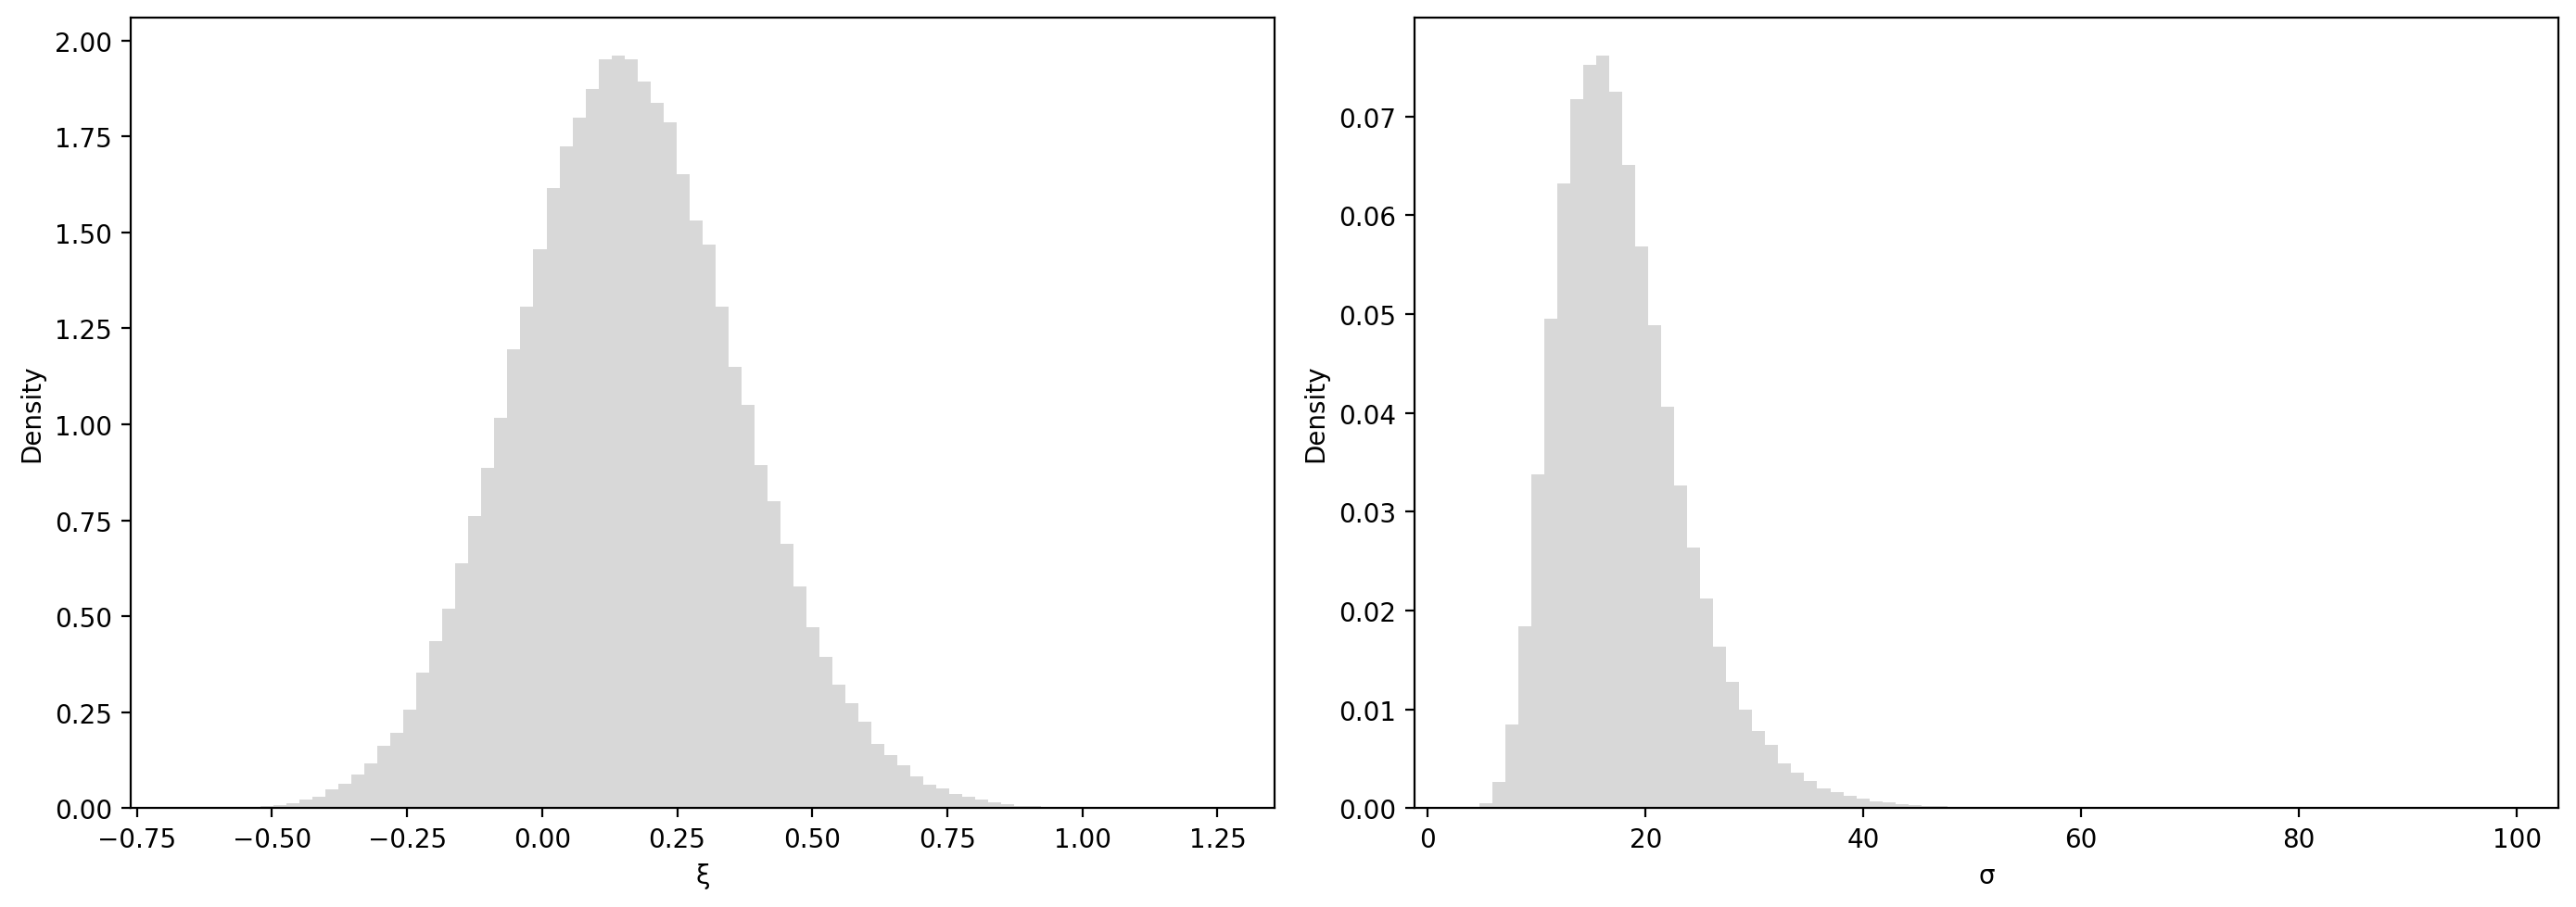

In [21]:
# xi ~ SkewNormal(alpha=1.2668, loc=0.0201, scale=0.1892)
alpha_xi = 1.27
loc_xi   = 0.0201
scale_xi = 0.1892

alpha_xi = 1.0
loc_xi   = 0.02
scale_xi = 0.25

# log_sigma ~ StudentT(df=95.92, loc=2.83, scale=0.32)
df_ls   = 95.92
loc_ls  = 2.83
scale_ls = 0.32

N = 200000
xi_samples = skewnorm.rvs(alpha_xi, loc=loc_xi, scale=scale_xi, size=N)
log_sigma_samples = t.rvs(df_ls, loc=loc_ls, scale=scale_ls, size=N)
sigma_samples = np.exp(log_sigma_samples)

# Plot
fig, ax = plt.subplots(1, 2, figsize=(14, 5), dpi=200)

# ξ prior
ax[0].hist(xi_samples, bins=80, density=True, alpha=0.5, color="0.7")
ax[0].set_xlabel("ξ")
ax[0].set_ylabel("Density")

# σ prior
ax[1].hist(sigma_samples, bins=80, density=True, alpha=0.5, color="0.7")
ax[1].set_xlabel("σ")
ax[1].set_ylabel("Density")
plt.tight_layout()
plt.show()

## 3.2 GEV Priors

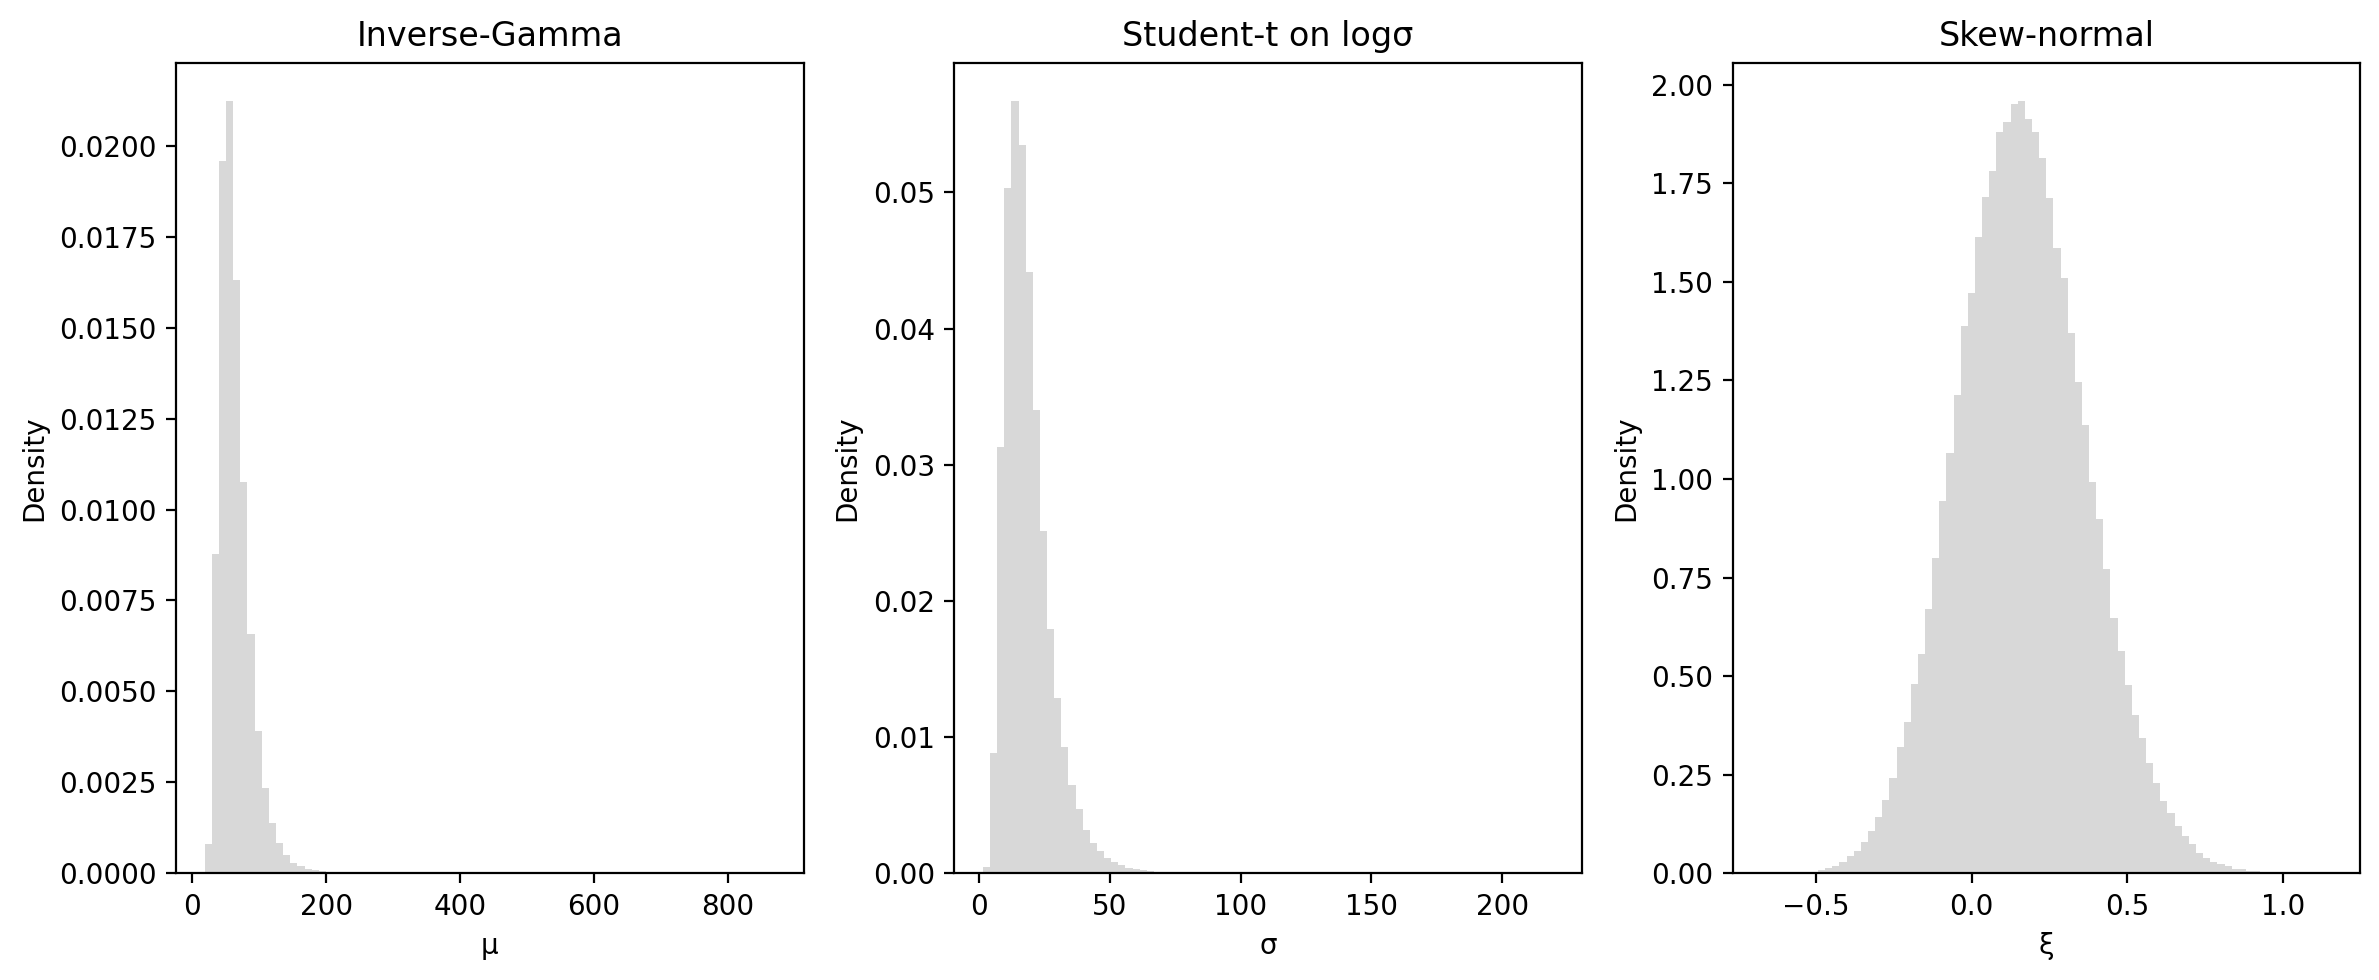

In [22]:
# mu ~ InverseGamma(alpha=9.2, beta=528.1)
alpha_mu = 9.2
beta_mu  = 528.1

# log_sigma ~ StudentT(df=2.29, loc=2.20, scale=0.91)
df_lsb   = 95.92
loc_lsb  = 2.83
scale_lsb = 0.45

# xi ~ SkewNormal(alpha=-0.2495, loc=-2.70, scale=3.6677) <= need to flip signs
alpha_xib = 0.25
loc_xib   = 2.7
scale_xib = 3.67

alpha_xib = 1.0
loc_xib   = 0.02
scale_xib = 0.25

# Draw samples
N = 200000
mu_samples = invgamma.rvs(alpha_mu, scale=beta_mu, size=N)
log_sigma_samples_bm = t.rvs(df_lsb, loc=loc_lsb, scale=scale_lsb, size=N)
sigma_samples_bm = np.exp(log_sigma_samples_bm)
xi_samples_bm = skewnorm.rvs(alpha_xib, loc=loc_xib, scale=scale_xib, size=N)

# Plot
fig, ax = plt.subplots(1, 3, figsize=(12, 5), dpi=200)
# μ prior
ax[0].hist(mu_samples, bins=80, density=True, alpha=0.5, color="0.7")
ax[0].set_title("Inverse‑Gamma")
ax[0].set_xlabel("μ")
ax[0].set_ylabel("Density")
# σ prior
ax[1].hist(sigma_samples_bm, bins=80, density=True, alpha=0.5, color="0.7")
ax[1].set_title("Student‑t on logσ")
ax[1].set_xlabel("σ")
ax[1].set_ylabel("Density")
# ax[1].set_xscale("log")

# ξ prior
ax[2].hist(xi_samples_bm, bins=80, density=True, alpha=0.5, color="0.7")
ax[2].set_title("Skew‑normal")
ax[2].set_xlabel("ξ")
ax[2].set_ylabel("Density")
plt.tight_layout()
plt.show()

# 4.0 Bayesian MCMC fitting

## 4.1 Run model: GPD

In [23]:
results_gpd = {}
predictions_gpd = {}

for i, sta in enumerate(station_ids):
    rng_key = jax.random.PRNGKey(1000 + i)

    # Keep as pandas Series because pyextremes requires the datetime index
    s_imp = grn_rainfall_imput[sta].dropna()
    u = pots_thr.loc[pots_thr.station_id == sta, "pots_thr"].iloc[0]

    # POT extraction with 24-hour declustering
    pot = get_extremes(
        ts=s_imp,
        method="POT",
        extremes_type="high",
        threshold=float(u),
        r="24h",
    )

    # Excesses above threshold
    y = pot.to_numpy() - u
    y = jnp.asarray(y)

    kernel = NUTS(model_gpd, target_accept_prob=0.98)
    mcmc = MCMC(kernel, num_warmup=2000, num_samples=1000, num_chains=4,)
    mcmc.run(rng_key, y)
    samples = mcmc.get_samples()
    predictive = Predictive(model_gpd, posterior_samples=samples)
    pp = predictive(jax.random.PRNGKey(12345),y)

    idata = az.from_numpyro(mcmc, posterior_predictive=pp, log_likelihood=True)

    results_gpd[sta] = {
        "threshold": float(u),
        "n_exceedances": len(y),
        "mcmc": mcmc,
        "samples": samples,
    }

    predictions_gpd[sta] = idata

    clear_output(wait=True)

# export trace plots
for sta in station_ids:
    fig = plt.figure(figsize=(10, 6), dpi=200)
    az.plot_trace(predictions_gpd[sta])
    plt.tight_layout()
    plt.savefig(
        rf"Outputs\BAYES_MCMC\BAYES_MCMC_TRACE\GPD_{sta}.png",
        dpi=200,
        bbox_inches="tight"
    )
    plt.close('all')

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

## 4.2 GEV

In [24]:
results_gev = {}
predictions_gev = {}

for i, sta in enumerate(station_ids):
    rng_key=jax.random.PRNGKey(1000 + i)

    obs = grn_rainfall_imput[sta].groupby(lambda x:x.year).max().dropna().to_numpy()

    kernel = NUTS(model_gev, target_accept_prob= 0.98)
    mcmc = MCMC(kernel,num_warmup=2000, num_samples=1000,num_chains=4)
    mcmc.run(rng_key, obs)
    samples = mcmc.get_samples()

    predictive = Predictive(model_gev, posterior_samples=samples)
    pp = predictive(jax.random.PRNGKey(12345), obs)

    idata = az.from_numpyro(
            mcmc,
            posterior_predictive=pp,
            log_likelihood=True,
    )

    results_gev[sta] = {
        "mcmc": mcmc,
        "samples": samples,
    }
    predictions_gev[sta] = idata

    clear_output(wait=True)

# export trace plots
for sta in station_ids:
    fig = plt.figure(figsize=(10, 6), dpi=200)
    az.plot_trace(predictions_gev[sta])
    plt.tight_layout()
    plt.savefig(
        rf"Outputs\BAYES_MCMC\BAYES_MCMC_TRACE\GEV_{sta}.png",
        dpi=200,
        bbox_inches="tight"
    )
    plt.close('all')

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

## 4.3 Save parameters

### 4.3.1 Samples

In [25]:
for sta in station_ids:
    pd.DataFrame(results_gev[sta]['samples']).to_csv(rf'Outputs\BAYES_MCMC\BAYES_MCMC_PARAMS\{sta}_GEV_samples.csv', index=False)
    pd.DataFrame(results_gpd[sta]['samples']).to_csv(rf'Outputs\BAYES_MCMC\BAYES_MCMC_PARAMS\{sta}_GPD_samples.csv', index=False)

### 4.3.2 Summary

In [26]:
param_summary = pd.DataFrame({'station_id': station_ids})

for i, sta in enumerate(station_ids):
    gev = az.summary(predictions_gev[sta])
    gpd = az.summary(predictions_gpd[sta])

    param_summary.loc[i, 'gev_sigma'] = np.exp(gev.loc['log_sigma', 'mean'])
    param_summary.loc[i, 'gev_sigma_5'] = np.exp(gev.loc['log_sigma', 'hdi_3%'])
    param_summary.loc[i, 'gev_sigma_95'] = np.exp(gev.loc['log_sigma', 'hdi_97%'])
    param_summary.loc[i, 'gev_sigma_rhat'] = gev.loc['log_sigma', 'r_hat']

    param_summary.loc[i, 'gev_mu'] = gev.loc['mu', 'mean']
    param_summary.loc[i, 'gev_mu_5'] = gev.loc['mu', 'hdi_3%']
    param_summary.loc[i, 'gev_mu_95'] = gev.loc['mu', 'hdi_97%']
    param_summary.loc[i, 'gev_mu_rhat'] = gev.loc['mu', 'r_hat']

    param_summary.loc[i, 'gev_xi'] = gev.loc['xi', 'mean']
    param_summary.loc[i, 'gev_xi_5'] = gev.loc['xi', 'hdi_3%']
    param_summary.loc[i, 'gev_xi_95'] = gev.loc['xi', 'hdi_97%']
    param_summary.loc[i, 'gev_xi_rhat'] = gev.loc['xi', 'r_hat']

    param_summary.loc[i, 'gpd_sigma'] = np.exp(gpd.loc['log_sigma', 'mean'])
    param_summary.loc[i, 'gpd_sigma_5'] = np.exp(gpd.loc['log_sigma', 'hdi_3%'])
    param_summary.loc[i, 'gpd_sigma_95'] = np.exp(gpd.loc['log_sigma', 'hdi_97%'])
    param_summary.loc[i, 'gpd_sigma_rhat'] = gpd.loc['log_sigma', 'r_hat']

    param_summary.loc[i, 'gpd_xi'] = gpd.loc['xi', 'mean']
    param_summary.loc[i, 'gpd_xi_5'] = gpd.loc['xi', 'hdi_3%']
    param_summary.loc[i, 'gpd_xi_95'] = gpd.loc['xi', 'hdi_97%']
    param_summary.loc[i, 'gpd_xi_rhat'] = gpd.loc['xi', 'r_hat']

param_summary.to_csv(r'Outputs\BAYES_MCMC\BAYES_MCMC_PARAM_SUMMARY.csv', index=False)

# 4.3 Compute return levels

In [27]:
T = np.array([2, 5, 10, 25, 50, 75, 100])

post_dir = Path(r'Outputs\BAYES_MCMC')

rows = []

for sta in station_ids:

    gev_post = pd.read_csv(post_dir / rf'BAYES_MCMC_PARAMS\{sta}_GEV_samples.csv')
    gpd_post = pd.read_csv(post_dir / rf'BAYES_MCMC_PARAMS\{sta}_GPD_samples.csv')

    # GPD needs threshold and lambda
    u = pots_thr.loc[pots_thr.station_id == sta, "pots_thr"].iloc[0]
    lam = exceedance_rate_per_year(grn_rainfall_imput[sta], u)

    gev_row = {"station": sta, "dist": "GEV"}
    gpd_row = {"station": sta, "dist": "GPD"}

    # Summaries
    gev_summary = gev_return_levels_from_posterior(T, gev_post, quantiles=(0.05, 0.95))
    gpd_summary = gpd_return_levels_from_posterior(T, gpd_post, u=u, lam_per_year=lam, quantiles=(0.05, 0.95))

    for T_i in T:
        label = f"{T_i:g}"

        mask_gev = gev_summary["T"].astype(float) == float(T_i)
        row_gev = gev_summary.loc[mask_gev].iloc[0]

        gev_row[f"TR_{label}_mean"] = row_gev["mean"]
        gev_row[f"TR_{label}_std"]  = row_gev["std"]
        # gev_row[f"TR_{label}_5"]    = row_gev["q05"]
        # gev_row[f"TR_{label}_95"]   = row_gev["q95"]

        mask_gpd = gpd_summary["T"].astype(float) == float(T_i)
        row_gpd = gpd_summary.loc[mask_gpd].iloc[0]

        gpd_row[f"TR_{label}_mean"] = row_gpd["mean"]
        gpd_row[f"TR_{label}_std"]  = row_gpd["std"]
        # gpd_row[f"TR_{label}_5"]    = row_gpd["q05"]
        # gpd_row[f"TR_{label}_95"]   = row_gpd["q95"]

    rows.append(gev_row)
    rows.append(gpd_row)

geva_tr_post = pd.DataFrame(rows)
geva_tr_post.to_csv(r'Outputs/geva_tr_post.csv')

# 5.0 Correlation matrix

In [ ]:
stations = stations.rename(columns={'Stations': 'station_id'})
param_summary_ext = param_summary.merge(stations, on='station_id')

df_corr = param_summary_ext[['gev_sigma', 'gev_mu', 'gev_xi', 'gpd_sigma', 'gpd_xi', 'Elevation']]
corr = df_corr.corr()

# Upper triangle mask
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(6, 3), dpi=200)
ax = sns.heatmap(
    corr, mask=mask, cmap="coolwarm", vmin=-1, vmax=1, center=0,
    annot=True, fmt=".2f", linewidths=0.5,
    cbar_kws={"shrink": 0.75, "pad": 0.005}
)

cbar = ax.collections[0].colorbar
cbar.set_label(r'Pearson Correlation Coefficient ($\rho$)', fontsize=10)
plt.tight_layout()
plt.show()